In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import itertools
import os
import random
from tqdm import tqdm
import multiprocessing



sys.path.append("/home/iscb/wolfson/hagairavid/ligand_alligner")
from utils.constants import LIGAND_DIR

BIO_LIP_COLUMNS = [
"PDB ID",
"Receptor chain",
"Resolution. '-1.00' stands for lack of resolution information, e.g. for NMR",
"Binding site number code",
"Ligand_ID",
"Ligand_chain",
"Ligand serial number",
"    Binding site residues (with PDB residue numbering)",
"    Binding site residues (with residue re-numbered starting from 1)",
"Catalytic site residues (different sites are separated by ';') (with PDB residue numbering)",
"    Catalytic site residues (different sites are separated by ';') (with residue re-numbered starting from 1)",
"EC number",
"GO terms",
"Binding affinity by manual survey of the original literature. The information in '()' is the PubMed ID",
"Binding affinity provided by the Binding MOAD database. The information in '()' is the ligand information in Binding MOAD",
"Binding affinity provided by the PDBbind-CN database. The information in '()' is the ligand information in PDBbind-CN",
"Binding affinity provided by the BindingDB database",
"UniProt ID",
"PubMed ID",
"Residue sequence number of the ligand (field _atom_site.auth_seq_id in PDBx/mmCIF format)",
"Receptor sequence"]


In [2]:
df = pd.read_csv('/home/iscb/wolfson/hagairavid/databases/BioLiP_nr.txt', sep="\t", header=None, names=BIO_LIP_COLUMNS)


/tmp/ipykernel_2445678/3788710865.py:1: DtypeWarning: Columns (13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/iscb/wolfson/hagairavid/databases/BioLiP_nr.txt', sep="\t", header=None, names=BIO_LIP_COLUMNS)


In [3]:
# Specify the path to your TSV file
tsv_file = 'ligand.tsv.gz'

# Read the TSV file into a DataFrame
ligands_df = pd.read_csv(tsv_file, sep='\t', encoding='utf-8', on_bad_lines='skip')
# print(ligands_df['#CCD'].index)
ligands_df.set_index(ligands_df.columns[0], inplace=True)
# ligands_df['SMILES'] = ligands_df['SMILES'].str.split(';').str[0]

ligands_df.to_csv('ligands.csv')

## Filter relevant columns

In [4]:
ligands_df.columns[0]

'formula'

## Filter relevant columns

In [5]:
relevant_columns = ["PDB ID", "Receptor chain", "Ligand_ID", "Ligand_chain"]
df = df[relevant_columns].astype('str')
df.shape


(76610, 4)

## Filter ligands with less than 2 proteins

In [6]:
value_counts = df["Ligand_ID"].value_counts()
values_to_keep = value_counts[value_counts > 1].index
df = df[df["Ligand_ID"].isin(values_to_keep)]
df = df[df["Ligand_chain"]=='A']
df.shape


(32196, 4)

## Leave unique ligand chain per ligand

In [7]:
# filtered_df = df.groupby(["Ligand_ID", "PDB ID"]).apply(lambda x: x.loc[x['Receptor chain'].idxmin()])
filtered_df = df.groupby(["Ligand_ID", "PDB ID"]).apply(lambda x: x.loc[x['Ligand_chain'].idxmin()])
filtered_df.shape


/tmp/ipykernel_2445678/2046154261.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby(["Ligand_ID", "PDB ID"]).apply(lambda x: x.loc[x['Ligand_chain'].idxmin()])


(22886, 4)

# plot ligand histogram

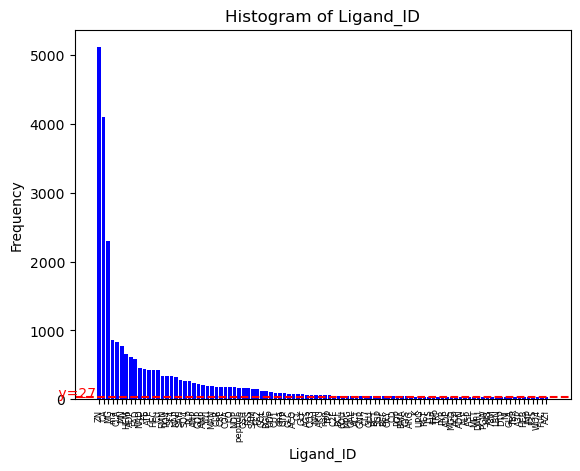

In [8]:
column_to_plot = "Ligand_ID"
value_counts = df[column_to_plot].value_counts()

# Plot the histogram
plt.bar(value_counts.index[:100], value_counts.values[:100], color='blue')
plt.xticks(fontsize=6)  # Adjust the font size as per your preference
# Extract the height of the last bar
last_bar_height = value_counts.values[:100][-1]

# Plot a horizontal line parallel to the x-axis at the height of the last bar
plt.axhline(y=last_bar_height, color='red', linestyle='--')
plt.text(-10, last_bar_height, f' y={last_bar_height}', color='red', fontsize=10)


# Rotate x-axis labels for better readability if needed
plt.xticks(rotation=90)

# Add labels and title
plt.xlabel(column_to_plot)
plt.ylabel('Frequency')
plt.title('Histogram of {}'.format(column_to_plot))

# Show plot
plt.show()

In [9]:
value_counts = df["Ligand_ID"].value_counts()
# Example usage:
pairs_per_ligand = value_counts.apply(lambda x: x*(x-1)//2)
    
# Compute the total number of pairs
total_pairs = pairs_per_ligand.sum()
print("Total number of pairs:", total_pairs)

Total number of pairs: 26878995


## Cath relationthip between pairs

In [10]:
cath_chains = pd.read_csv('/home/iscb/wolfson/hagairavid/databases/cath-domain-list.txt',sep='\s+', names=['pdb_chain', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k'], skiprows=16)
# cath_chains = cath_chains.set_index('pdb_chain')
cath_chains['domain'] = cath_chains['pdb_chain'].str[-2:]
cath_chains['chain'] = cath_chains['pdb_chain'].str[:-2]


In [11]:

def compare_rows(row1, row2):
    unequal_indices = np.where(row1 != row2)[0]
    if len(unequal_indices) == 0:
        return len(row1)
    else:
        return unequal_indices[0]

In [12]:
from rdkit import Chem


def compute_heavy_atoms(smiles):
        # Split multiple SMILES by semicolon and compute heavy atoms for each
        smiles_list = smiles.split(';')
        heavy_atoms_counts = []
        for smi in smiles_list:
            if smi[-1] == ';':
                 smi = smi[:-1]
            mol = Chem.MolFromSmiles(smi.strip())  # Strip whitespace around each SMILES string
            if mol is not None:
                heavy_atoms_counts.append(mol.GetNumHeavyAtoms())
        return heavy_atoms_counts


## Calculate CATH degree

In [13]:
# Define your existing logic for processing pairs within a function
def process_pairs(combinations, unique_pairs, result_rows, missing_chains):
    
    for row1, row2 in combinations:
        row1 = row1[1]
        row2 = row2[1]

        if row1['PDB ID'] != row2['PDB ID'] and (row1.iloc[0], row2.iloc[0]) not in unique_pairs and (row2.iloc[0], row1.iloc[0]) not in unique_pairs:
            unique_pairs.add((row1.iloc[0], row2.iloc[0]))
            chain1 = f"{row1['PDB ID']}{row1['Receptor chain']}"
            chain2 = f"{row2['PDB ID']}{row2['Receptor chain']}"

            if chain1 in missing_chains or chain2 in missing_chains:
                continue

            chain1_domains = cath_chains[cath_chains['chain'] == chain1]
            if chain1_domains.empty:
                missing_chains.add(chain1)
                continue

            chain2_domains = cath_chains[cath_chains['chain'] == chain2]
            if chain2_domains.empty:
                missing_chains.add(chain2)
                continue

            max_similarity = -1
            for _, domain1 in chain1_domains.iterrows():
                for _, domain2 in chain2_domains.iterrows():
                    max_similarity = max(max_similarity, compare_rows(domain1.values[1:9], domain2.values[1:9]))

            result_rows.append([row1['PDB ID'], row2['PDB ID'], row1['Receptor chain'], row2['Receptor chain'], row2['Ligand_ID'], max_similarity, heavy_atom_count])
            if len(result_rows) % 10000 == 0:
                print(len(result_rows))


In [14]:

all_combinations = []
for i, ligand_id in tqdm(enumerate(df["Ligand_ID"].unique()), desc="Processing Ligand_IDs"):
    try:
        smiles = ligands_df.loc[ligand_id]['SMILES']
    except KeyError:
        print(f"{ligand_id} is missing from BioLip database.")
        continue
    heavy_atom_count = compute_heavy_atoms(smiles)
    if heavy_atom_count is not None and len(heavy_atom_count) > 0:
        heavy_atom_count = max(heavy_atom_count)
        # print(f"{ligand_id} has up to {heavy_atom_count} heavy atoms.")
        if heavy_atom_count < 10:
            continue
    else:
        print(f"Could not calculate heavy atom count for ligand {ligand_id}.")
        continue

    filtered_rows = df[df['Ligand_ID'] == ligand_id]
    # print(f"Process ligand {ligand_id}, n chains is  {filtered_rows.shape[0]}")
    
    all_combinations += list(itertools.combinations(filtered_rows.iterrows(), 2))[:10000]

result_rows = multiprocessing.Manager().list()  # Use Manager to create a shared list
missing_chains = set()  
unique_pairs = set() 
    
num_processes = multiprocessing.cpu_count()
chunk_size = max(len(all_combinations) // num_processes, 1)
chunks = [all_combinations[i:i + chunk_size] for i in range(0, len(all_combinations), chunk_size)]
with multiprocessing.Pool(processes=num_processes) as pool:
    pool.starmap(process_pairs, [(chunk, unique_pairs, result_rows, missing_chains) for chunk in chunks])

result_df = pd.DataFrame(list(result_rows), columns=['ref_protein', 'mov_protein', 'ref_chain', 'mov_chain', 'ligand_id', 'CATH_degree', 'ligand_n_atoms'])
result_df.to_csv(os.path.join('calculated_cath', f'{result_df.shape[0]}.csv'))

Processing Ligand_IDs: 3it [00:00, 17.33it/s][09:14:46] SMILES Parse Error: syntax error while parsing: CC1=C(CCC(O)=O)C2=Cc3n4[Fe]5|6|N2=C1C=c7n5c(=CC8=N|6C(=Cc4c(C)c3CCC(O)=O)C(=C8C=C)C)c(C)c7C=C
[09:14:46] SMILES Parse Error: Failed parsing SMILES 'CC1=C(CCC(O)=O)C2=Cc3n4[Fe]5|6|N2=C1C=c7n5c(=CC8=N|6C(=Cc4c(C)c3CCC(O)=O)C(=C8C=C)C)c(C)c7C=C' for input: 'CC1=C(CCC(O)=O)C2=Cc3n4[Fe]5|6|N2=C1C=c7n5c(=CC8=N|6C(=Cc4c(C)c3CCC(O)=O)C(=C8C=C)C)c(C)c7C=C'
Processing Ligand_IDs: 14it [00:00, 37.55it/s]

nan is missing from BioLip database.


Processing Ligand_IDs: 35it [00:00, 54.30it/s][09:14:47] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10
[09:14:47] Can't kekulize mol.  Unkekulized atoms: 4 5 6 7 8
[09:14:47] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
Processing Ligand_IDs: 76it [00:01, 110.00it/s][09:14:47] SMILES Parse Error: syntax error while parsing: Cl[Pt+]|1|2|n3ccccc3c4cccc(n|14)c5ccccn|25
[09:14:47] SMILES Parse Error: Failed parsing SMILES 'Cl[Pt+]|1|2|n3ccccc3c4cccc(n|14)c5ccccn|25' for input: 'Cl[Pt+]|1|2|n3ccccc3c4cccc(n|14)c5ccccn|25'
[09:14:47] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17


dna is missing from BioLip database.


Processing Ligand_IDs: 104it [00:01, 150.78it/s][09:14:47] Can't kekulize mol.  Unkekulized atoms: 7 8 15 16 17
Processing Ligand_IDs: 121it [00:01, 136.88it/s][09:14:47] Explicit valence for atom # 34 N, 4, is greater than permitted
[09:14:47] SMILES Parse Error: syntax error while parsing: C[Co++]|12|3|N4=C5C=C6N|1=C([CH](CCC(N)=O)C6(C)C)C(=C7[N-]2=C([CH](CC(N)=O)[C]7(C)CCC(=O)NC[CH](C)O[P](O)(=O)O[CH]8[CH](O)[CH](O[CH]8CO)n9cnc%10cc(C)c(C)cc9%10)[C]%11(C)N|3=C([CH](CCC(N)=O)[C]%11(C)CC(N)=O)C(=C4[C](C)(CC(N)=O)[CH]5CCC(N)=O)C)C
[09:14:47] SMILES Parse Error: Failed parsing SMILES 'C[Co++]|12|3|N4=C5C=C6N|1=C([CH](CCC(N)=O)C6(C)C)C(=C7[N-]2=C([CH](CC(N)=O)[C]7(C)CCC(=O)NC[CH](C)O[P](O)(=O)O[CH]8[CH](O)[CH](O[CH]8CO)n9cnc%10cc(C)c(C)cc9%10)[C]%11(C)N|3=C([CH](CCC(N)=O)[C]%11(C)CC(N)=O)C(=C4[C](C)(CC(N)=O)[CH]5CCC(N)=O)C)C' for input: 'C[Co++]|12|3|N4=C5C=C6N|1=C([CH](CCC(N)=O)C6(C)C)C(=C7[N-]2=C([CH](CC(N)=O)[C]7(C)CCC(=O)NC[CH](C)O[P](O)(=O)O[CH]8[CH](O)[CH](O[CH]8CO)n9cnc%10cc(C)c(C

...

Could not calculate heavy atom count for ligand TEW.
Could not calculate heavy atom count for ligand PQJ.
Could not calculate heavy atom count for ligand ZRW.
Could not calculate heavy atom count for ligand R5Q.
Could not calculate heavy atom count for ligand SIW.


Processing Ligand_IDs: 1637it [00:05, 366.96it/s][09:14:52] Can't kekulize mol.  Unkekulized atoms: 12 13 14 15 16 17 18 19 20
[09:14:52] Explicit valence for atom # 0 Be, 4, is greater than permitted
[09:14:52] Explicit valence for atom # 23 Be, 4, is greater than permitted
[09:14:52] Explicit valence for atom # 23 Be, 4, is greater than permitted
[09:14:52] Explicit valence for atom # 0 Be, 4, is greater than permitted
[09:14:52] Can't kekulize mol.  Unkekulized atoms: 5 6 7 8 9
Processing Ligand_IDs: 1711it [00:05, 351.01it/s]

Could not calculate heavy atom count for ligand 08T.


Processing Ligand_IDs: 1750it [00:05, 361.06it/s][09:14:52] Can't kekulize mol.  Unkekulized atoms: 17 18 19 20 21 22 23 24 25
Processing Ligand_IDs: 1826it [00:06, 299.60it/s]


10000
20000
30000
40000
50000
60000
70000
80000
9000090000

100000
100000
110000


In [15]:
asdsa
matching_columns = []
result_rows = []
os.makedirs('calculated_cath', exist_ok=True)

missing_chains, exist_chains = set(), set()
for i, ligand_id in tqdm(enumerate(df["Ligand_ID"].unique()), desc="Processing Ligand_IDs"):
    try:
        smiles = ligands_df.loc[ligand_id]['SMILES']
    except KeyError:
        print(f"{ligand_id} is missing from BioLip database.")
        continue
    heavy_atom_count = compute_heavy_atoms(smiles)
    if heavy_atom_count is not None and len(heavy_atom_count) > 0:
        heavy_atom_count = max(heavy_atom_count)
        # print(f"{ligand_id} has up to {heavy_atom_count} heavy atoms.")
        if heavy_atom_count < 10:
            continue
    else:
        print(f"Could not calculate heavy atom count for ligand {ligand_id}.")
        continue

    num_of_pairs = 0
    filtered_rows = df[df['Ligand_ID'] == ligand_id]
    print(f"Process ligand {ligand_id}, n chains is  {filtered_rows.shape[0]}")
    # ligand_repo = os.path.join(f"/home/iscb/wolfson/hagairavid/ligand_alligner/{LIGAND_DIR}", id)
    # pairs_file = os.path.join(ligand_repo, f"{id}.txt")
    # os.makedirs(ligand_repo, exist_ok=True)
  
    unique_pairs = set()
    
    # with open(pairs_file, "w") as output_file:
    combinations = list(itertools.combinations(filtered_rows.iterrows(), 2))
    random.shuffle(combinations)
    for row1, row2 in combinations:
        row1 = row1[1]
        row2 = row2[1]
        if row1['PDB ID'] != row2['PDB ID'] and (row1.iloc[0], row2.iloc[0]) not in  unique_pairs and (row2.iloc[0], row1.iloc[0]) not in  unique_pairs:
            unique_pairs.add((row1.iloc[0], row2.iloc[0]))
            chain1 = f"{row1['PDB ID']}{row1['Receptor chain']}"
            chain2 = f"{row2['PDB ID']}{row2['Receptor chain']}"
            if chain1 in missing_chains or chain2 in missing_chains:
                continue
            chain1_domains: pd.DataFrame = cath_chains[cath_chains['chain'] == chain1]
            if chain1_domains.empty:
                missing_chains.add(chain1)
                continue
            exist_chains.add(chain1)
            chain2_domains: pd.DataFrame = cath_chains[cath_chains['chain'] == chain2]
            if chain2_domains.empty:
                missing_chains.add(chain2)
                continue

            exist_chains.add(chain2)
            num_of_pairs +=1

            max_similarity = -1
            for _, domain1 in chain1_domains.iterrows():
                for _, domain2 in chain2_domains.iterrows():
                    max_similarity = max(max_similarity, compare_rows(domain1.values[1:9], domain2.values[1:9]))
            result_rows.append([row1['PDB ID'], row2['PDB ID'], row1['Receptor chain'], row2['Receptor chain'], ligand_id, max_similarity, heavy_atom_count])
            if len(result_rows) % 1000 == 0:
                result_df = pd.DataFrame(result_rows, columns=['ref_protein', 'mov_protein', 'ref_chain', 'mov_chain', 'ligand_id', 'CATH_degree', 'ligand_n_atoms'])
                result_df.to_csv(os.path.join('calculated_cath',f'{result_df.shape[0]}.csv'))
            matching_columns.append(max_similarity)
            # output_file.write(f"{row1['PDB ID']}:{row1['Receptor chain']} {row2['PDB ID']}:{row2['Receptor chain']} {max_similarity}\n")
            if num_of_pairs > 10000:
                break
result_df = pd.DataFrame(result_rows, columns=['ref_protein', 'mov_protein', 'ref_chain', 'mov_chain', 'ligand_id', 'CATH_degree', 'ligand_n_atoms'])
result_df.to_csv(os.path.join('calculated_cath',f'{result_df.shape[0]}.csv'))



NameError: name 'asdsa' is not defined

In [16]:
print(result_df.shape)
result_df.head()

(110191, 7)


,ref_protein,mov_protein,ref_chain,mov_chain,ligand_id,CATH_degree,ligand_n_atoms
0,10mh,1af7,A,A,SAH,4,12
1,10mh,1boo,A,A,SAH,4,12
2,10mh,1cbf,A,A,SAH,2,12
3,10mh,1dl5,A,A,SAH,4,12
4,10mh,1f3l,A,A,SAH,4,12


CATH_degree
4    36047
1    28452
2    23378
0    12194
3     8643
5     1065
6      364
8       29
7       19
Name: count, dtype: int64


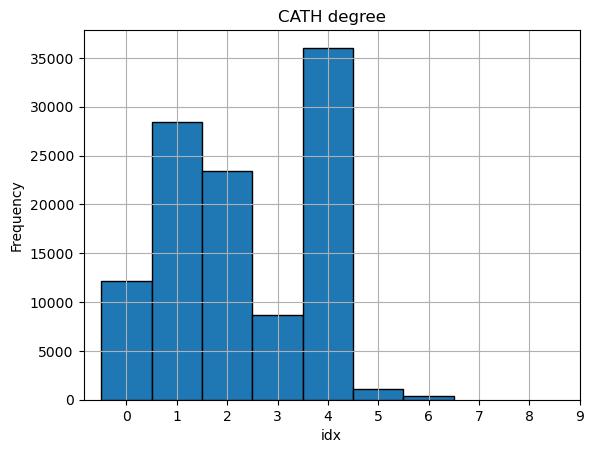

In [24]:

print(result_df['CATH_degree'].value_counts())
plt.hist(result_df['CATH_degree'], bins=range(8), align='left', edgecolor='black')

plt.xlabel('idx')
plt.ylabel('Frequency')
plt.title('CATH degree')
plt.xticks(range(10))
plt.grid(True)
plt.show()

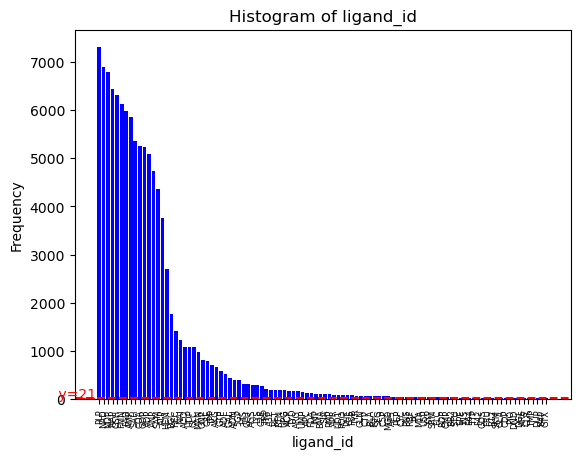

In [18]:
column_to_plot = "ligand_id"
value_counts = result_df[column_to_plot].value_counts()
plt.bar(value_counts.index[:100], value_counts.values[:100], color='blue')
plt.xticks(fontsize=6)  
last_bar_height = value_counts.values[:100][-1]
plt.axhline(y=last_bar_height, color='red', linestyle='--')
plt.text(-10, last_bar_height, f' y={last_bar_height}', color='red', fontsize=10)
plt.xticks(rotation=90)
plt.xlabel(column_to_plot)
plt.ylabel('Frequency')
plt.title(f'Histogram of {column_to_plot}')
plt.show()

In [49]:
ligand_freq = result_df['ligand_id'].value_counts()
cath_degree_freq = result_df['CATH_degree'].value_counts()

def calculate_probability(row):
    ligand_prob = 1 / np.sqrt(ligand_freq[row['ligand_id']])
    cath_prob = 1 / np.sqrt(cath_degree_freq[row['CATH_degree']])
    return ligand_prob * cath_prob

result_df['Probability'] = result_df.apply(calculate_probability, axis=1)
result_df['Probability'] /= result_df['Probability'].sum()

print(result_df['Probability'])

0         0.000003
1         0.000003
2         0.000003
3         0.000003
4         0.000003
            ...   
110186    0.000002
110187    0.000002
110188    0.000002
110189    0.000003
110190    0.000002
Name: Probability, Length: 110191, dtype: float64


In [50]:
sampled_rows = np.random.choice(result_df.index, size=10000, replace=False, p=result_df['Probability'])
sampled_df = result_df.loc[sampled_rows]

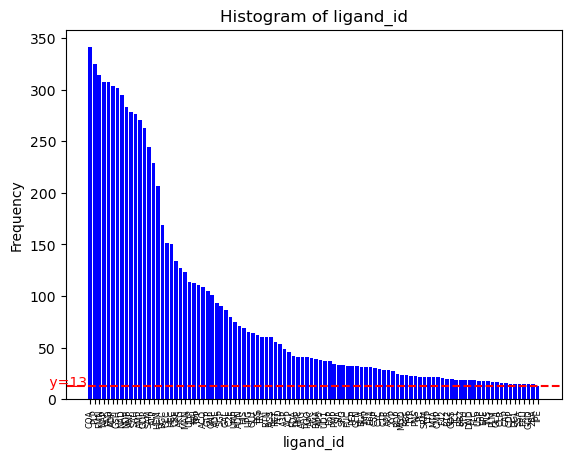

In [51]:
column_to_plot = "ligand_id"
value_counts = sampled_df[column_to_plot].value_counts()

# Plot the histogram
plt.bar(value_counts.index[:100], value_counts.values[:100], color='blue')
plt.xticks(fontsize=6)  # Adjust the font size as per your preference
# Extract the height of the last bar
last_bar_height = value_counts.values[:100][-1]

plt.axhline(y=last_bar_height, color='red', linestyle='--')
plt.text(-10, last_bar_height, f' y={last_bar_height}', color='red', fontsize=10)
plt.xticks(rotation=90)
plt.xlabel(column_to_plot)
plt.ylabel('Frequency')
plt.title('Histogram of {}'.format(column_to_plot))

# Show plot
plt.show()

CATH_degree
4    2395
1    2148
0    1757
2    1723
3    1117
5     553
6     261
8      27
7      19
Name: count, dtype: int64


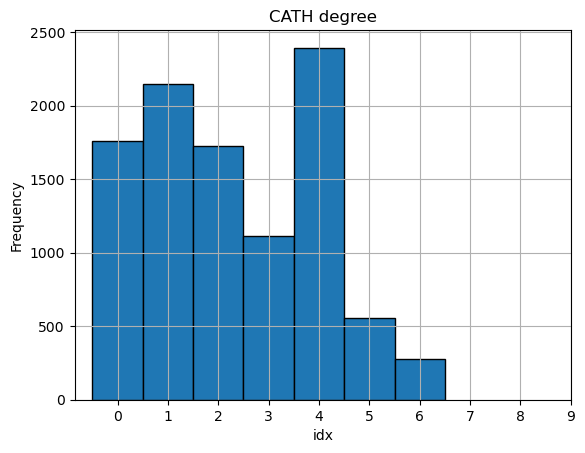

In [52]:

print(sampled_df['CATH_degree'].value_counts())
plt.hist(sampled_df['CATH_degree'], bins=range(8), align='left', edgecolor='black')

plt.xlabel('idx')
plt.ylabel('Frequency')
plt.title('CATH degree')
plt.xticks(range(10))
plt.grid(True)
plt.show()

In [53]:
sampled_df.head()

,ref_protein,mov_protein,ref_chain,mov_chain,ligand_id,CATH_degree,ligand_n_atoms,Probability
20325,1n8p,5ohx,A,A,PLP,2,12,0.000003
95748,1hm8,4xpl,A,A,ACO,1,12,0.000006
35828,1icp,3oix,A,A,FMN,4,12,0.000002
86969,1b3o,1nfb,A,A,CPR,4,12,0.000108
29220,3odu,3oe6,A,A,ITD,7,12,0.008120
